In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
def get_gamma(zbin=3, dirname='../data/meas/sas'):
    gamma = np.load(os.path.join(dirname, 'gam-zbin{0}{0}{0}.npy'.format(zbin)))
    logr = np.loadtxt(os.path.join(dirname, 'logr.txt'))
    phi = np.loadtxt(os.path.join(dirname, 'phi.txt'))
    r = np.exp(logr)
    return r, phi, gamma

def get_meas_diag(mu, phi_in, zbin=3, dirname='../data/meas/sas'):
    gamma = np.load(os.path.join(dirname, 'gam-zbin{0}{0}{0}.npy'.format(zbin)))
    logr = np.loadtxt(os.path.join(dirname,'logr.txt'))
    phi = np.loadtxt(os.path.join(dirname,'phi.txt'))
    r = np.exp(logr)

    idx = np.argmin(np.abs(phi-phi_in))
    print(phi[idx])

    return r, np.diag(gamma[mu, :,:, idx])

def get_theo_diag(mu, phi_in, zbin=3):
    gamma = np.loadtxt('../output/2pt-plus-3pt/ggg/gamma-real-bin_{0},bin_{0},bin_{0}.txt'.format(zbin)) + 1j*np.loadtxt('../output/2pt-plus-3pt/ggg/gamma-imag-bin_{0},bin_{0},bin_{0}.txt'.format(zbin))
    t1 = np.loadtxt('../output/2pt-plus-3pt/ggg/t1.txt')
    t1 = np.rad2deg(t1)*60.0
    phi = np.loadtxt('../output/2pt-plus-3pt/ggg/phi.txt')
    gamma = np.reshape(gamma, (4, phi.size, t1.size, t1.size))

    idx = np.argmin(np.abs(phi-phi_in))
    print(phi[idx])

    return t1, np.diag(gamma[mu, idx, :,:])

0.5811946381818182
0.5811946409141118


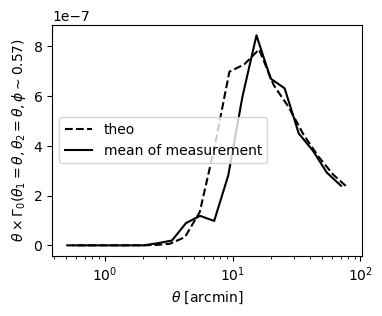

In [5]:
fig, ax = plt.subplots(1,1, figsize=(4,3))

i = 2

phi = np.linspace(0,1,n)[i]*np.pi

ax.set_xscale('log')
ax.set_xlabel(r'$\theta$ [arcmin]')
ax.set_ylabel(r'$\theta\times\Gamma_0(\theta_1=\theta, \theta_2=\theta, \phi\sim{:.2f})$'.format(phi))

# theory
r, gamma = get_theo_diag(0, phi, zbin)
# ax.plot(r, r*np.real(gamma), color='red', ls='--')
# ax.plot(r, r*np.imag(gamma), color='blue', ls='--')
ax.plot(r, r*np.abs(gamma), color='black', ls='--', label='theo')
#ax.set_ylim(-1e-6, 1e-6)
# measurement
r, gamma = get_meas_diag(0, phi, zbin, dirname='../data/meas/sas2')
# ax.plot(r, r*np.real(gamma), color='red', label='real')
# ax.plot(r, r*np.imag(gamma), color='blue', label='imag')
ax.plot(r, r*np.abs(gamma), color='black', label='mean of measurement')
# plt.axvspan(1e-2, 0.5, color='gray', alpha=0.5)
# plt.axvspan(80, 1e5, color='gray', alpha=0.5)
#ax.set_xlim(1e-2, 1e5)
ax.legend()

plt.show()

0.01570796
0.015707963267948967
0.2984512990909091
0.2984513020910304
0.5811946381818182
0.5811946409141118
0.8639379772727273
0.8639379797371932
1.1466813163636365
1.1466813185602744
1.4294246554545456
1.429424657383356
1.7121679945454547
1.7121679962064373
1.9949113336363637
1.9949113350295187
2.2776546727272726
2.2776546738526
2.5603980118181817
2.5603980126756816
2.843141350909091
2.843141351498763
3.12588469
3.1258846903218442


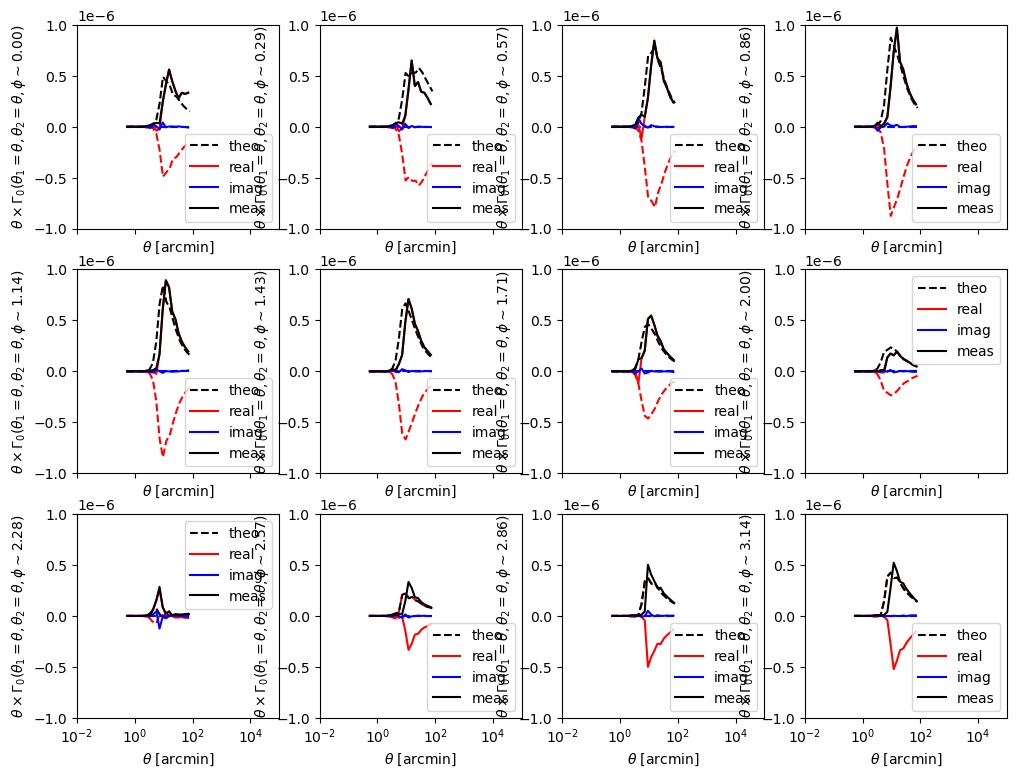

In [4]:
zbin = 4

n = 12
fig, axes = plt.subplots(3,4, figsize=(3*4,3*3), sharex=True)#, sharey=True)
axes = np.reshape(axes, -1)

for i in range(n):
    phi = np.linspace(0,1,n)[i]*np.pi

    ax = axes[i]
    ax.set_xscale('log')
    ax.set_xlabel(r'$\theta$ [arcmin]')
    ax.set_ylabel(r'$\theta\times\Gamma_0(\theta_1=\theta, \theta_2=\theta, \phi\sim{:.2f})$'.format(phi))
    # theory
    r, gamma = get_theo_diag(0, phi, zbin)
    ax.plot(r, r*np.real(gamma), color='red', ls='--')
    ax.plot(r, r*np.imag(gamma), color='blue', ls='--')
    ax.plot(r, r*np.abs(gamma), color='black', ls='--', label='theo')
    ax.set_ylim(-1e-6, 1e-6)
    # measurement
    r, gamma = get_meas_diag(0, phi, zbin, dirname='../data/meas/sas2')
    ax.plot(r, r*np.real(gamma), color='red', label='real')
    ax.plot(r, r*np.imag(gamma), color='blue', label='imag')
    ax.plot(r, r*np.abs(gamma), color='black', label='meas')
    # plt.axvspan(1e-2, 0.5, color='gray', alpha=0.5)
    # plt.axvspan(80, 1e5, color='gray', alpha=0.5)
    ax.set_xlim(1e-2, 1e5)
    ax.legend()

plt.show()

In [4]:
r, phi, gamma = get_gamma()

Text(0.5, 1.0, '$(\\theta_1\\theta_2)^{1/2}\\Gamma_0(\\theta_1, \\theta_2, \\phi=0.016)$')

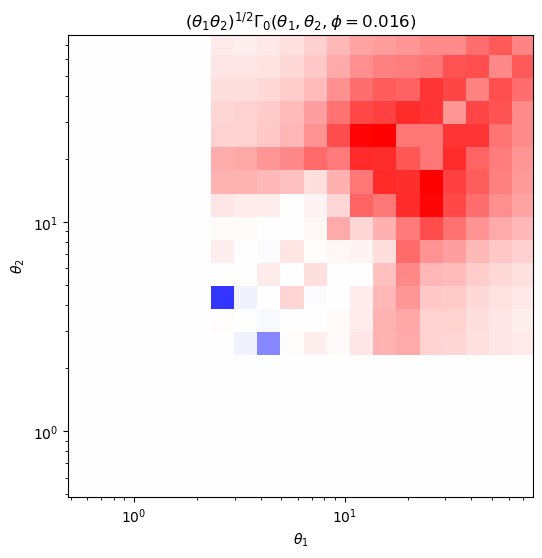

In [5]:
idx= 0
plt.figure(figsize=(6,6))
plt.xscale('log')
plt.yscale('log')
z = (r[:,None]*r[None,:])**0.5*gamma[0, :, :, idx].real
plt.pcolormesh(r,r,z, cmap='bwr', vmin=-z.max(), vmax=z.max())
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.title(r'$(\theta_1\theta_2)^{{1/2}}\Gamma_0(\theta_1, \theta_2, \phi={:.2})$'.format(phi[idx]))